=== EXPLORATORY DATA ANALYSIS - FOOTBALL MATCHES ===



Saving matches.csv to matches (3).csv
1. BASIC DATASET OVERVIEW
----------------------------------------
Dataset shape: (887, 6)
Date range: 1984-04-08 00:00:00 to 2025-07-27 00:00:00
Total matches: 887


,datetime,home_team,away_team,home_goals,away_goals,result
0,1984-04-08,England,Denmark,2,1,Home Win
1,1984-04-08,Italy,Sweden,2,3,Away Win
2,1984-04-28,Denmark,England,0,1,Away Win
3,1984-04-28,Sweden,Italy,2,1,Home Win
4,1984-05-12,Sweden,England,1,0,Home Win



2. MATCH RESULTS DISTRIBUTION
----------------------------------------
result
Home Win    480
Away Win    303
Draw        104
Name: count, dtype: int64

Home Win Percentage: 54.1%
Away Win Percentage: 34.2%
Draw Percentage: 11.7%

3. GOALS ANALYSIS
----------------------------------------
Average home goals: 1.82
Average away goals: 1.34
Average total goals: 3.15
Highest scoring match: 13 goals
Most common score: 1-1


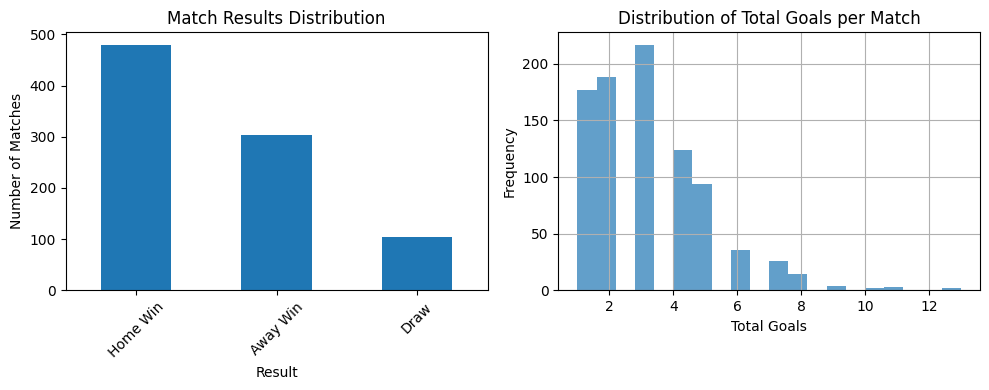


4. HOME VS AWAY PERFORMANCE
----------------------------------------
Home win rate: 54.1%
Away win rate: 34.2%
Draw rate: 11.7%

5. CORRELATION ANALYSIS
----------------------------------------


,home_goals,away_goals,total_goals
home_goals,1.000000,-0.291373,0.678076
away_goals,-0.291373,1.000000,0.505527
total_goals,0.678076,0.505527,1.000000


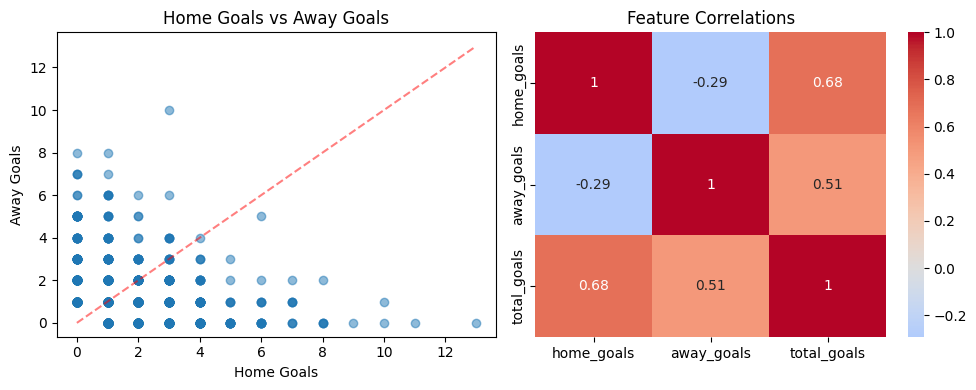


6. SEASONAL TRENDS
----------------------------------------


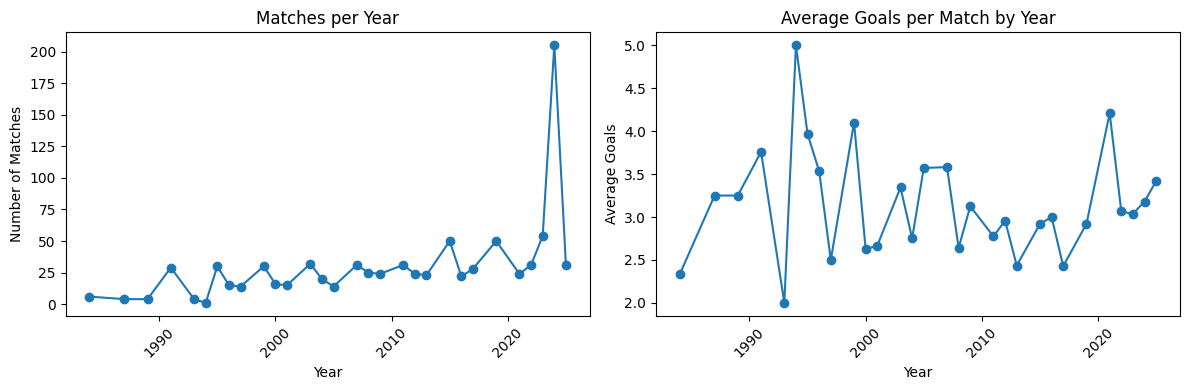


7. TEAM PERFORMANCE ANALYSIS
----------------------------------------


,count
Germany,129
Sweden,126
Norway,106
United States,92
England,76
Brazil,72
France,71
Japan,61
Denmark,61
Italy,58


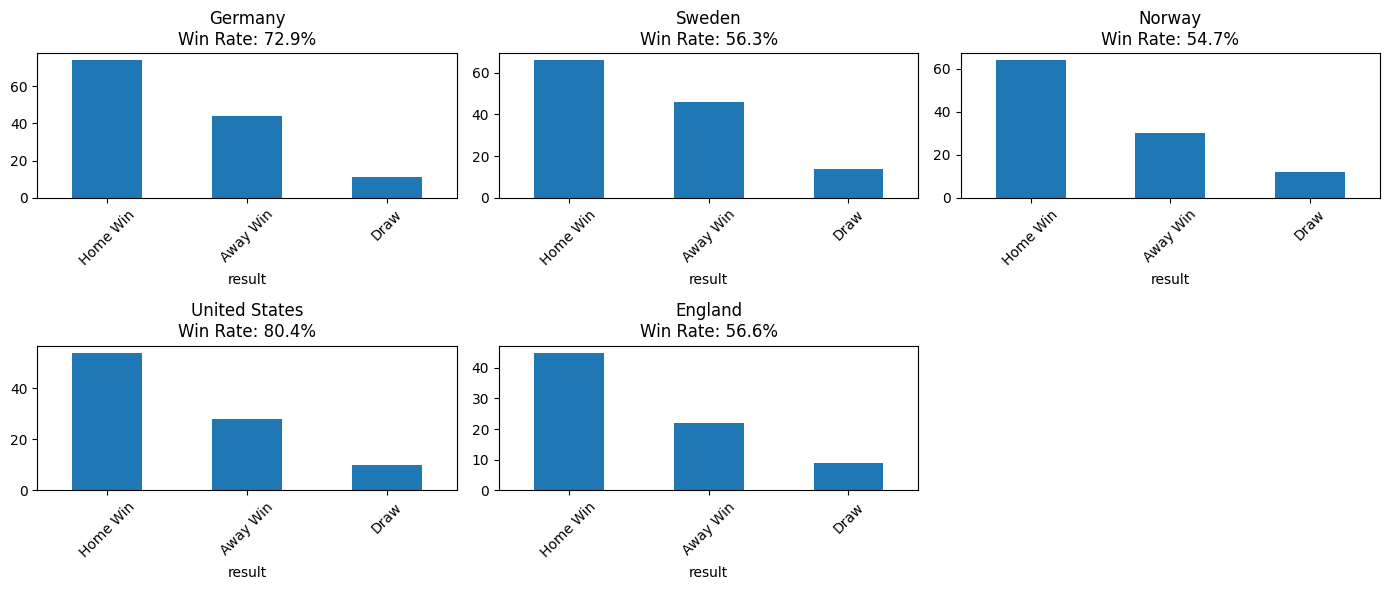


8. KEY INSIGHTS SUMMARY
----------------------------------------
• Home teams win about 54.1% of matches
• The average match has 3.2 total goals
• Most common result type: Home Win
• Correlation between home goals and total goals: 0.68
• Number of matches has increased over time

=== EDA COMPLETE ===


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from google.colab import files

print("=== EXPLORATORY DATA ANALYSIS - FOOTBALL MATCHES ===\n")

uploaded = files.upload()
matches = pd.read_csv("matches.csv")
matches["datetime"] = pd.to_datetime(matches["datetime"], errors="coerce")

matches['result'] = np.where(matches['home_goals'] > matches['away_goals'], 'Home Win',
                            np.where(matches['home_goals'] < matches['away_goals'], 'Away Win', 'Draw'))

print("1. BASIC DATASET OVERVIEW")
print("-" * 40)
print(f"Dataset shape: {matches.shape}")
print(f"Date range: {matches['datetime'].min()} to {matches['datetime'].max()}")
print(f"Total matches: {len(matches)}")
display(matches.head())

print("\n2. MATCH RESULTS DISTRIBUTION")
print("-" * 40)
result_counts = matches["result"].value_counts()
print(result_counts)

total_n = len(matches)
print(f"\nHome Win Percentage: {(result_counts.get('Home Win', 0)/total_n*100):.1f}%")
print(f"Away Win Percentage: {(result_counts.get('Away Win', 0)/total_n*100):.1f}%")
print(f"Draw Percentage: {(result_counts.get('Draw', 0)/total_n*100):.1f}%")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
result_counts.plot(kind="bar")
plt.title("Match Results Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)

print("\n3. GOALS ANALYSIS")
print("-" * 40)

# Ensure 'total_goals' is calculated if not already present or parsed from CSV
# This block is moved here to ensure 'total_goals' exists before being processed in the loop
if 'total_goals' not in matches.columns:
    matches['total_goals'] = matches['home_goals'] + matches['away_goals']

for col in ["home_goals", "away_goals", "total_goals"]:
    matches[col] = pd.to_numeric(matches[col], errors="coerce")

print(f"Average home goals: {matches['home_goals'].mean():.2f}")
print(f"Average away goals: {matches['away_goals'].mean():.2f}")

print(f"Average total goals: {matches['total_goals'].mean():.2f}")
print(f"Highest scoring match: {matches['total_goals'].max()} goals")

home_mode = matches["home_goals"].mode()
away_mode = matches["away_goals"].mode()
if len(home_mode) and len(away_mode):
    print(f"Most common score: {int(home_mode.iloc[0])}-{int(away_mode.iloc[0])}")

plt.subplot(1, 2, 2)
matches["total_goals"].hist(bins=20, alpha=0.7)
plt.title("Distribution of Total Goals per Match")
plt.xlabel("Total Goals")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("\n4. HOME VS AWAY PERFORMANCE")
print("-" * 40)
home_win_rate = (matches["result"] == "Home Win").mean()
away_win_rate = (matches["result"] == "Away Win").mean()
draw_rate = (matches["result"] == "Draw").mean()

print(f"Home win rate: {home_win_rate*100:.1f}%")
print(f"Away win rate: {away_win_rate*100:.1f}%")
print(f"Draw rate: {draw_rate*100:.1f}%")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(matches["home_goals"], matches["away_goals"], alpha=0.5)
max_goals = int(np.nanmax([matches["home_goals"].max(), matches["away_goals"].max()]))
plt.plot([0, max_goals], [0, max_goals], "r--", alpha=0.5)
plt.title("Home Goals vs Away Goals")
plt.xlabel("Home Goals")
plt.ylabel("Away Goals")

print("\n5. CORRELATION ANALYSIS")
print("-" * 40)
numeric_cols = [c for c in ["home_goals", "away_goals", "total_goals", "penalty_goals", "own_goals"] if c in matches.columns]
correlation_matrix = matches[numeric_cols].corr()
display(correlation_matrix)

plt.subplot(1, 2, 2)
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlations")
plt.tight_layout()
plt.show()

print("\n6. SEASONAL TRENDS")
print("-" * 40)
matches["year"] = matches["datetime"].dt.year
matches_per_year = matches["year"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
matches_per_year.plot(kind="line", marker="o")
plt.title("Matches per Year")
plt.xlabel("Year")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)

goals_per_year = matches.groupby("year")["total_goals"].mean()
plt.subplot(1, 2, 2)
goals_per_year.plot(kind="line", marker="o")
plt.title("Average Goals per Match by Year")
plt.xlabel("Year")
plt.ylabel("Average Goals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n7. TEAM PERFORMANCE ANALYSIS")
print("-" * 40)
home_matches = matches["home_team"].value_counts()
away_matches = matches["away_team"].value_counts()
total_matches = home_matches.add(away_matches, fill_value=0).sort_values(ascending=False)
display(total_matches.head(10))

top_teams = total_matches.head(5).index.tolist()

def team_win_rate(df, team):
    home_wins = ((df["home_team"] == team) & (df["result"] == "Home Win")).sum()
    away_wins = ((df["away_team"] == team) & (df["result"] == "Away Win")).sum()
    games = ((df["home_team"] == team) | (df["away_team"] == team)).sum()
    return 100 * (home_wins + away_wins) / games if games > 0 else np.nan

plt.figure(figsize=(14, 6))
for i, team in enumerate(top_teams, 1):
    team_df = matches[(matches["home_team"] == team) | (matches["away_team"] == team)]
    wr = team_win_rate(matches, team)
    plt.subplot(2, 3, i)
    team_df["result"].value_counts().plot(kind="bar")
    plt.title(f"{team}\nWin Rate: {wr:.1f}%")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\n8. KEY INSIGHTS SUMMARY")
print("-" * 40)
trend = "increased" if matches_per_year.iloc[-1] > matches_per_year.iloc[0] else "decreased"

print(f"• Home teams win about {home_win_rate*100:.1f}% of matches")
print(f"• The average match has {matches['total_goals'].mean():.1f} total goals")
print(f"• Most common result type: {result_counts.index[0]}")
print(f"• Correlation between home goals and total goals: {correlation_matrix.loc['home_goals','total_goals']:.2f}")
print(f"• Number of matches has {trend} over time")

print("\n=== EDA COMPLETE ===")